# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

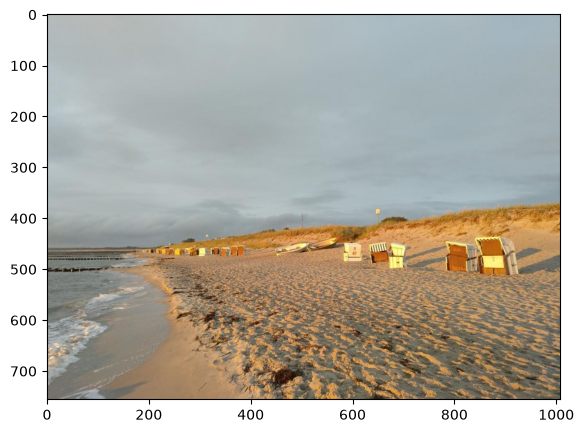

In [2]:
img = cv2.imread('../data/sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x783d70cfec30>)

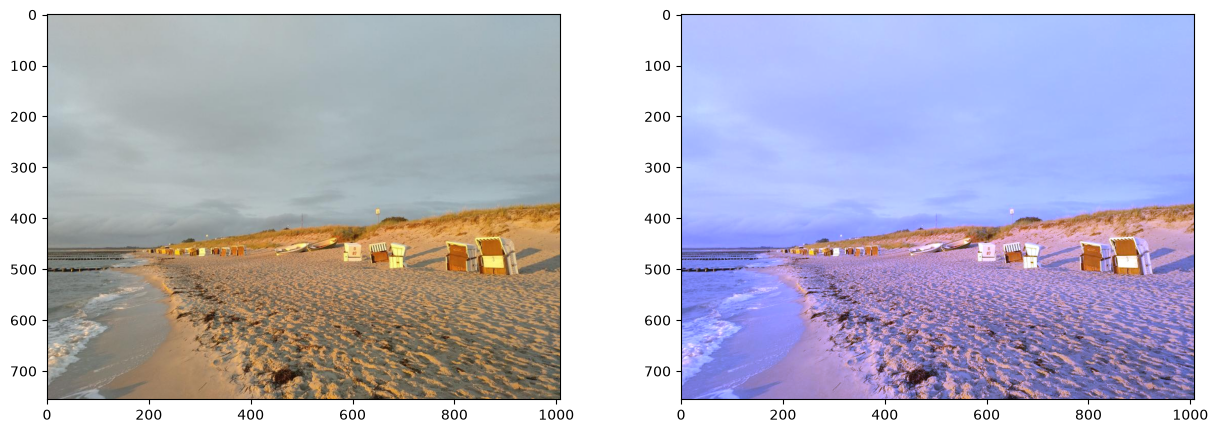

In [3]:
# Define white patch and the coefficients
row, col = 485, 864 
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

mean_r = 123.19066685267858
mean_g = 109.93705008370536
mean_b = 112.89218052455357


(<Axes: >, <matplotlib.image.AxesImage at 0x783d69b65910>)

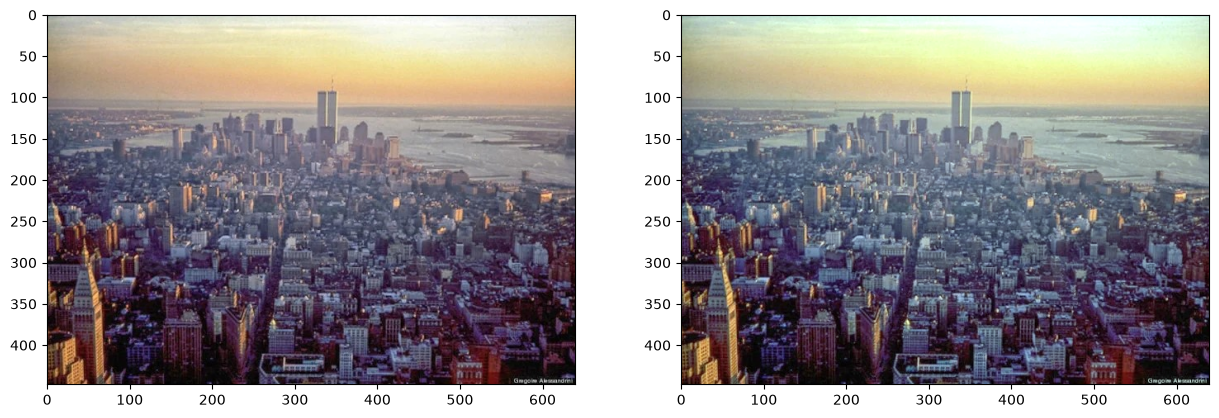

In [17]:
# Load your image
img = cv2.imread('../data/new-york-city-skyline.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
red, green, blue = cv2.split(img)
mean_r = np.mean(red)
mean_g = np.mean(green)
mean_b = np.mean(blue)
print(f"mean_r = {mean_r}")
print(f"mean_g = {mean_g}")
print(f"mean_b = {mean_b}")
mean_max = max(mean_r, mean_g, mean_b)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = mean_max / mean_r
kg = mean_max / mean_g
kb = mean_max / mean_b

# Apply color balancing and generate the balanced image
bal_r = np.clip(red * kr, 0, 255).astype(np.uint8)
bal_g = np.clip(green * kg, 0, 255).astype(np.uint8)
bal_b = np.clip(blue * kb, 0, 255).astype(np.uint8)
balanced = cv2.merge([bal_r, bal_g, bal_b])

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

max_r = 255
max_g = 255
max_b = 255


(<Axes: >, <matplotlib.image.AxesImage at 0x783d69bfcef0>)

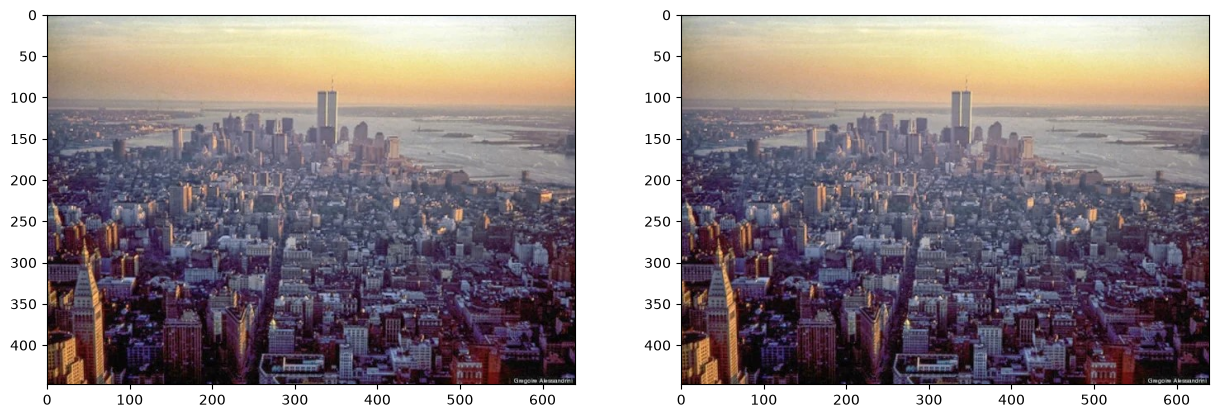

In [15]:
# Load your image
img = cv2.imread('../data/new-york-city-skyline.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
red, green, blue = cv2.split(img)
max_r = np.max(red)
max_g = np.max(green)
max_b = np.max(blue)
print(f"max_r = {max_r}")
print(f"max_g = {max_g}")
print(f"max_b = {max_b}")

# Apply scale-by-max balancing and generate the balanced image
balanced = cv2.merge([red / max_r, green / max_g, blue / max_b])

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)